In [30]:
import numpy as np

# 1. Загрузка скрытых состояний Transformer
hidden_trf = np.load('/Users/taniyashuba/PycharmProjects/NeuroSymbolicDynamics/train models/hidden_trf.npy')  # shape (500, 10, 32)

# 2. Склейка по временной оси
# Вариант A: просто concatenate все шаги подряд
hidden_flat = hidden_trf.reshape(-1, hidden_trf.shape[2])  # shape (5000, 32)

# Вариант B: если хочется анализировать только последнее состояние каждого примера:
# hidden_flat = hidden_trf[:, -1, :]                      # shape (500, 32)

# Дальше hidden_flat играет роль нашего массива h_t (аналогично hidden_states для RNN)
N, d = hidden_flat.shape
print(f"Flattened hidden states shape: {N} × {d}")

Flattened hidden states shape: 5000 × 32


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
import networkx as nx  # добавлено для символического графа

In [32]:
# Параметры embedding
tau, m, k = 1, 3, 4

In [33]:
# 3. Time‐delay embedding
embedded = []
for i in range(N - (m-1)*tau):
    vec = hidden_flat[i]
    for j in range(1, m):
        vec = np.concatenate([vec, hidden_flat[i + j*tau]], axis=0)
    embedded.append(vec)
X_td = np.array(embedded)  # shape (N_td, m*d)

In [34]:
# 4. Символизация k-means
km = KMeans(n_clusters=k, random_state=0).fit(X_td)
symbols = km.labels_

In [35]:
# 5. Матрица переходов
P = np.zeros((k,k)); counts = np.zeros(k)
for t in range(len(symbols)-1):
    i,j = symbols[t], symbols[t+1]
    P[i,j] += 1; counts[i] += 1
P_norm = (P.T/counts).T

In [36]:
# 6. LZ‐сложность
def lz_complexity(s):
    n,i,c,l = len(s),0,1,1
    while True:
        if i+l>n-1:
            c+=1; break
        if s[i:i+l] in s[:i+l-1]:
            l+=1
        else:
            c+=1; i+=l; l=1
        if i+l>n-1:
            c+=1; break
    return c

s_str = ''.join(map(str, symbols))
lz_val = lz_complexity(s_str)

In [37]:
# 7. Корреляционная размерность D2
dists = np.linalg.norm(X_td[:,None]-X_td[None,:], axis=2)
rs = np.logspace(-2,0,10)
C_vals = [(dists<r).sum()/(len(X_td)**2) for r in rs]
log_r, log_C = np.log(rs[:6]), np.log(C_vals[:6])
D2 = LinearRegression().fit(log_r.reshape(-1,1), log_C).coef_[0]

In [38]:
# 8. Mapper-граф
pca1 = PCA(1).fit(X_td); f_vals = pca1.transform(X_td).flatten()
n_bins = 5
min_f, max_f = f_vals.min(), f_vals.max()
span = (max_f-min_f)/(n_bins-(n_bins-1)*0.5)
bins = [(min_f+i*span*0.5, min_f+i*span*0.5+span) for i in range(n_bins)]
nodes, edges = [], []
for b,(low,high) in enumerate(bins):
    idxs = np.where((f_vals>=low)&(f_vals<=high))[0]
    if len(idxs)==0: continue
    sub = X_td[idxs]
    km2 = KMeans(2, random_state=0).fit(sub)
    for lbl in np.unique(km2.labels_):
        pts = set(idxs[km2.labels_==lbl])
        nodes.append({'name':f"{b}-{lbl}", 'bin':b, 'pts':pts})
for a in nodes:
    for b in nodes:
        if b['bin']==a['bin']+1 and a['pts']&b['pts']:
            edges.append((a['name'],b['name']))

# 9. Визуализация (те же четыре графика)

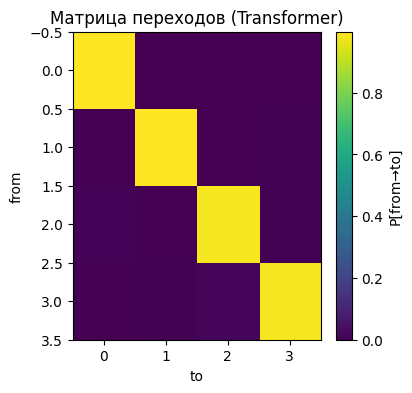

In [39]:
# 9.1 Heatmap переходов
plt.figure(figsize=(4,4))
plt.imshow(P_norm, aspect='auto', cmap='viridis')
plt.colorbar(label='P[from→to]')
plt.title('Матрица переходов (Transformer)')
plt.xlabel('to'); plt.ylabel('from')
plt.show()

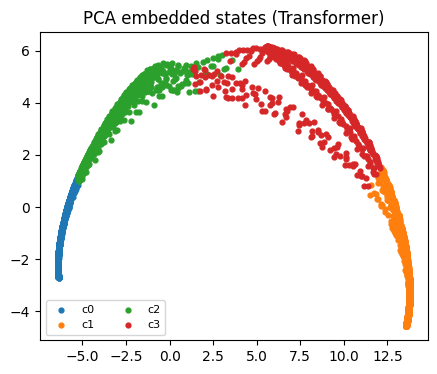

In [40]:
# 9.2 PCA-Scatter
pca2 = PCA(2).fit(X_td); coords2 = pca2.transform(X_td)
plt.figure(figsize=(5,4))
for sym in range(k):
    plt.scatter(coords2[symbols==sym,0], coords2[symbols==sym,1],
                label=f"c{sym}", s=12)
plt.legend(ncol=2, fontsize=8)
plt.title('PCA embedded states (Transformer)')
plt.show()

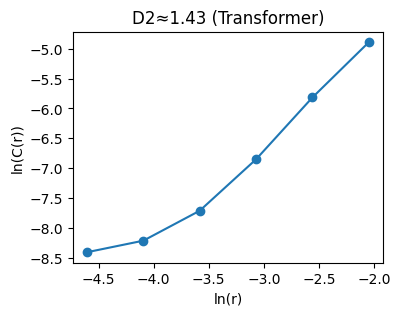

In [41]:
# 9.3 Correlation dimension
plt.figure(figsize=(4,3))
plt.plot(log_r, log_C, 'o-')
plt.title(f"D2≈{D2:.2f} (Transformer)")
plt.xlabel('ln(r)'); plt.ylabel('ln(C(r))')
plt.show()

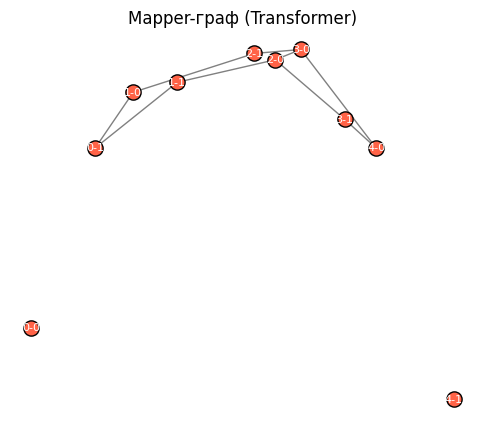

In [42]:
# 9.4 Mapper-граф
for n in nodes:
    pts = list(n['pts'])
    n['xy'] = coords2[pts].mean(axis=0)
plt.figure(figsize=(6,5))
lines = [[next(n for n in nodes if n['name']==s)['xy'],
          next(n for n in nodes if n['name']==t)['xy']]
         for s,t in edges]
lc = LineCollection(lines, colors='gray', linewidths=1)
ax = plt.gca(); ax.add_collection(lc)
for n in nodes:
    x,y = n['xy']
    plt.scatter(x,y,s=120,color='tomato',edgecolors='k',zorder=2)
    plt.text(x,y,n['name'],ha='center',va='center',color='white',fontsize=8)
plt.title('Mapper-граф (Transformer)')
plt.axis('off')
plt.show()

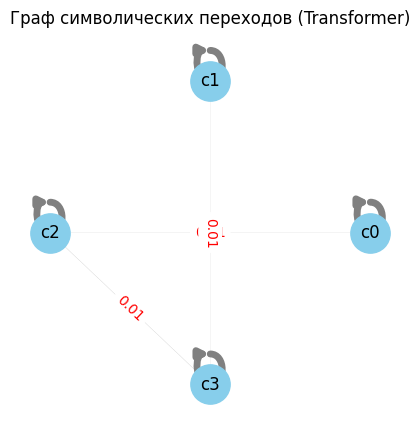

In [43]:
# 9.5 Символьный граф переходов
G = nx.DiGraph()
# Добавляем узлы-символы
for i in range(k):
    G.add_node(f"c{i}")
# Добавляем рёбра с весами из P_norm
for i in range(k):
    for j in range(k):
        w = P_norm[i, j]
        if w > 0:
            G.add_edge(f"c{i}", f"c{j}", weight=w)

plt.figure(figsize=(5,5))
pos = nx.circular_layout(G)
edge_widths = [G[u][v]['weight']*5 for u,v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_size=800, node_color='skyblue')
nx.draw_networkx_labels(G, pos, font_size=12)
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=12,
                       width=edge_widths, edge_color='gray')
edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')
plt.title("Граф символических переходов (Transformer)")
plt.axis('off')
plt.show()